<a href="https://colab.research.google.com/github/nileshgarg-tech/mortgage-ai-document-intelligence/blob/main/Bank_Loan_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bank Personal Loan Dataset Exploration

We are given a dataset with personal loan information for 5000 people and we are supposed to explore, analyze and clean it with the use of pandas. The link to the provided dataset is -
[Bank Personal Loan](https://www.kaggle.com/datasets/arezalo/bank-personal-loan/)

In [14]:
# Importing the library
import pandas as pd

In [15]:
# Loading the dataset
loans_df = pd.read_csv('/content/bank_loan.csv')

In [16]:
# Exploring Data
loans_df.head(10)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91108,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0/40,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1/50,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0/30,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0/60,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8/90,3,0,1,0,0,0,0


In [17]:
loans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  5000 non-null   int64 
 1   Age                 5000 non-null   int64 
 2   Experience          5000 non-null   int64 
 3   Income              5000 non-null   int64 
 4   ZIP Code            5000 non-null   int64 
 5   Family              5000 non-null   int64 
 6   CCAvg               5000 non-null   object
 7   Education           5000 non-null   int64 
 8   Mortgage            5000 non-null   int64 
 9   Personal Loan       5000 non-null   int64 
 10  Securities Account  5000 non-null   int64 
 11  CD Account          5000 non-null   int64 
 12  Online              5000 non-null   int64 
 13  CreditCard          5000 non-null   int64 
dtypes: int64(13), object(1)
memory usage: 547.0+ KB


In [18]:
# Checking for Null Values
loans_df.isna().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIP Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,0


We have no null values in the dataset here ...

In [19]:
# Converting Income from 1000s of dollars to dollars
loans_df['Income'] = loans_df['Income'] * 1000
display(loans_df[['Income']].head())

,Income
0,49000
1,34000
2,11000
3,100000
4,45000


In [20]:
# Converting Mortgage from 1000s of dollars to dollars
loans_df['Mortgage'] = loans_df['Mortgage'] * 1000
display(loans_df[['Mortgage']].head())

,Mortgage
0,0
1,0
2,0
3,0
4,0


In [21]:
# Converting CCAvg: replacing '/' with '.' and multiplying by 1000 to convert k to dollars
loans_df['CCAvg'] = loans_df['CCAvg'].str.replace('/', '.').astype(float) * 1000
display(loans_df[['CCAvg']].head())

,CCAvg
0,1600.0
1,1500.0
2,1000.0
3,2700.0
4,1000.0


### Rationale for Data Transformations

The following transformations were applied to ensure the dataset values reflect actual dollar amounts for analysis:

1. **Income & Mortgage**: These columns were originally provided in thousands of dollars (e.g., 49 representing $49,000). Multiplying by 1000 standardizes them to full dollar values.
2. **CCAvg**: This column used a unique shorthand string format (e.g., '1/60' for 1.60k). Replacing the slash with a decimal and multiplying by 1000 converts these entries into usable numeric dollar values.

In [23]:
display(loans_df.describe())

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73774.200000,93152.503200,2.396400,1937.93800,1.881000,56498.800000,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46033.729321,2121.852005,1.147663,1747.65898,0.839869,101713.802102,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8000.000000,9307.000000,1.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39000.000000,91911.000000,1.000000,700.00000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64000.000000,93437.000000,2.000000,1500.00000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98000.000000,94608.000000,3.000000,2500.00000,3.000000,101000.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224000.000000,96651.000000,4.000000,10000.00000,3.000000,635000.000000,1.000000,1.000000,1.00000,1.000000,1.000000


## Education-Level Demographic and Financial Analysis

To better understand the demographic and financial characteristics of the bank's customers, we will analyze the data based on their education levels.

### Education Level Mapping
The `Education` column in the dataset is encoded as follows:
- **1**: Undergrad
- **2**: Graduate
- **3**: Advanced/Professional

### Objective
The objective of this analysis is to explore demographic and financial disparities (such as income, mortgage, and loan uptake) across these three education levels to identify patterns in customer behavior and status.

### Financial Metrics Factor

Calculate and plot the mean Income and Mortgage values grouped by Education level.

I will calculate the mean Income and Mortgage grouped by Education and create a grouped bar chart to visualize the comparison between these financial metrics across different education levels.


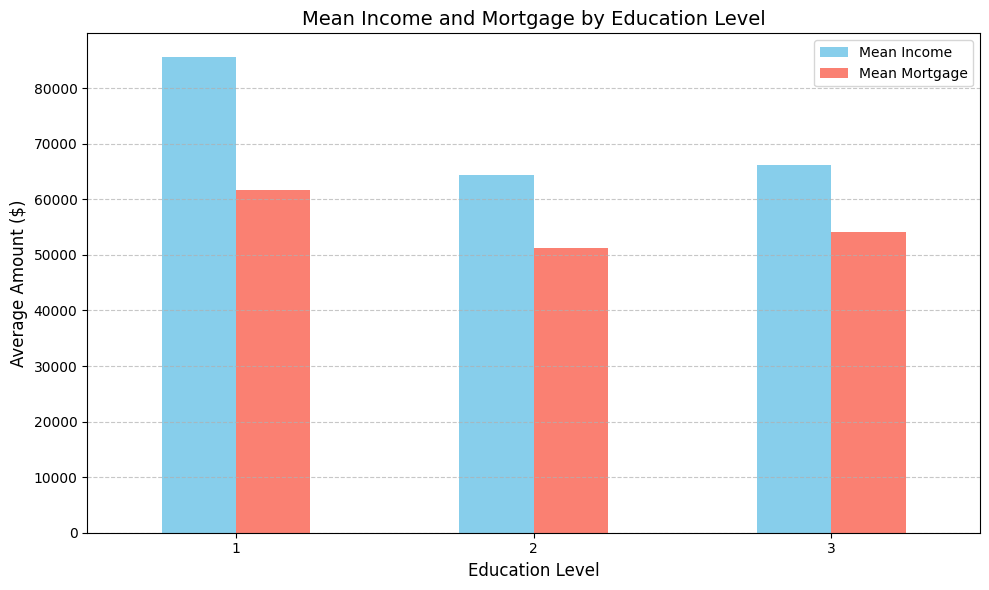

In [24]:
import matplotlib.pyplot as plt

# Grouping the data and calculating the mean for Income and Mortgage
education_means = loans_df.groupby('Education')[['Income', 'Mortgage']].mean()

# Plotting the mean values
ax = education_means.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'])

# Adding labels and title
plt.title('Mean Income and Mortgage by Education Level', fontsize=14)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Average Amount ($)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Mean Income', 'Mean Mortgage'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

### Banking Services Factor

Calculate and plot the adoption rates for Credit Cards, Online banking, Securities accounts, and CD accounts across the three Education levels.


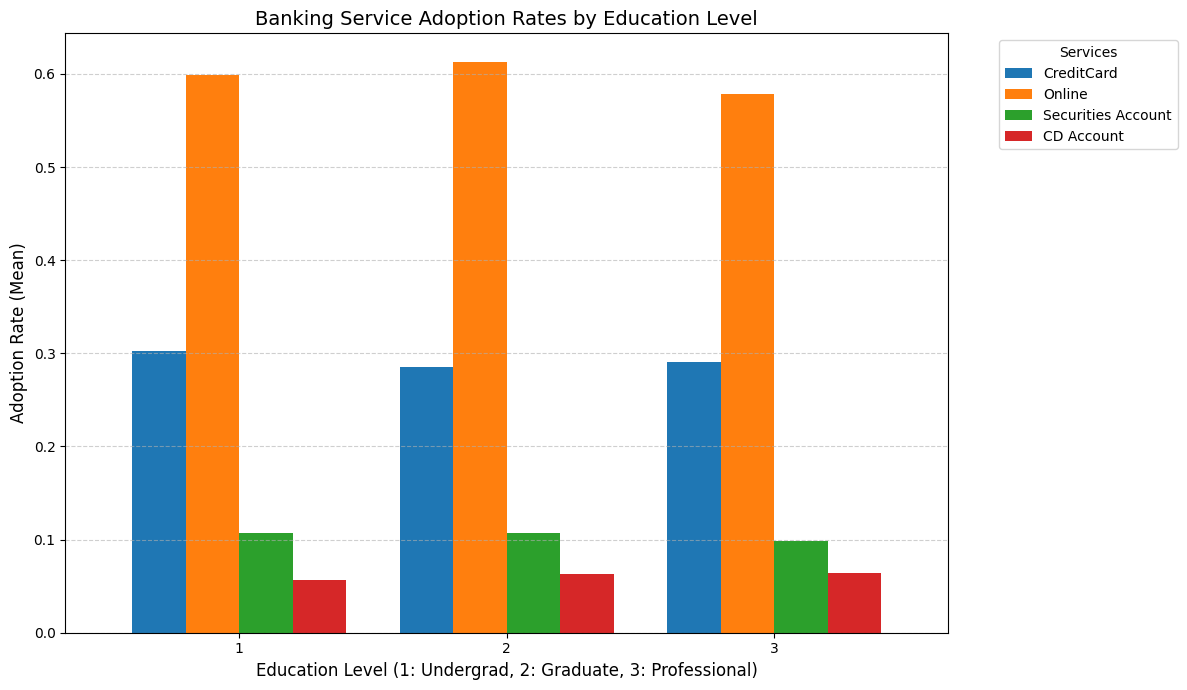

In [25]:
import matplotlib.pyplot as plt

# Define the service columns to analyze
service_cols = ['CreditCard', 'Online', 'Securities Account', 'CD Account']

# Group by Education and calculate the adoption rates (means)
service_adoption = loans_df.groupby('Education')[service_cols].mean()

# Plotting the adoption rates
ax = service_adoption.plot(kind='bar', figsize=(12, 7), width=0.8)

# Adding titles and labels
plt.title('Banking Service Adoption Rates by Education Level', fontsize=14)
plt.xlabel('Education Level (1: Undergrad, 2: Graduate, 3: Professional)', fontsize=12)
plt.ylabel('Adoption Rate (Mean)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Services', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

### Family Structure Factor

Calculate and plot the average Family size for each Education level to identify demographic differences.

I will calculate the mean family size grouped by education level and create a bar chart to visualize these demographic differences as requested in the subtask.


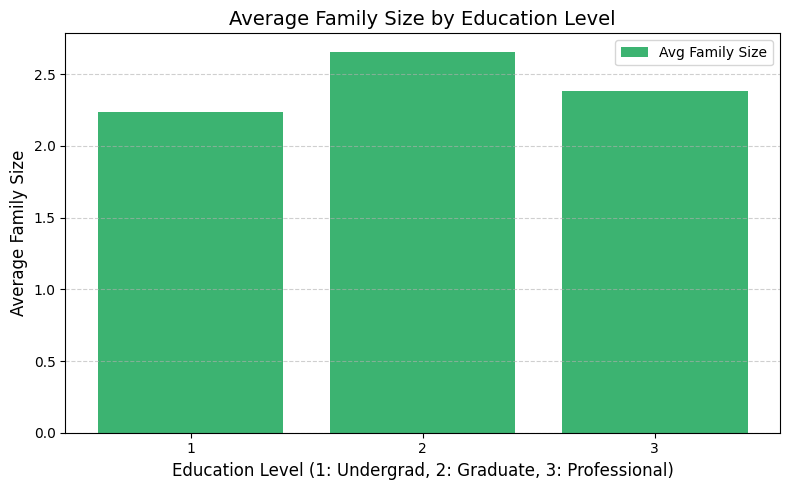

In [29]:
import matplotlib.pyplot as plt

# Grouping by Education and calculating mean Family size
avg_family_size = loans_df.groupby('Education')['Family'].mean()

# Plotting the average family size
plt.figure(figsize=(8, 5))
plt.bar(avg_family_size.index.astype(str), avg_family_size.values, color='mediumseagreen', label='Avg Family Size')

# Adding titles and labels
plt.title('Average Family Size by Education Level', fontsize=14)
plt.xlabel('Education Level (1: Undergrad, 2: Graduate, 3: Professional)', fontsize=12)
plt.ylabel('Average Family Size', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

### Summary of Analysis Findings

* **Income Disparities**: Undergraduates (Education Level 1) unexpectedly exhibit the highest mean income compared to Graduate and Professional segments, marking them as a high-value financial group.
* **Banking Habits**: Online banking adoption is consistently high across all education levels, suggesting that digital platforms are a universal standard for the bank's customer base.
* **Family Structure**: The Graduate segment (Education Level 2) typically has a larger average family size compared to undergraduates and professionals, indicating different household financial needs.
* **Service Adoption**: While standard services are common, specialized products like CD and Securities accounts show significant variation, with higher education groups showing slightly higher interest in long-term savings (CD accounts).
* **Strategic Targeting**: The bank should focus premium product marketing and wealth management services toward the undergraduate segment due to their higher average income and strong engagement with core banking services.

### Loan Analysis by Age
Analyze the demographic and financial disparities across different age groups in the personal bank loans dataset

Perform the following tasks:
1. **Age Grouping Introduction**: Create a markdown cell explaining the rationale for age-level analysis and defining the specific age bins (e.g., Young Adults, Middle-Aged, Seniors) that will be used for categorization.
2. **Financial Metrics by Age**: Create a code cell to bin the 'Age' column into the defined groups, calculate the mean Income and Mortgage for each group, and visualize these results using a bar chart with a legend.
3. **Banking Service Adoption by Age**: Create a code cell to calculate the adoption rates for Credit Cards, Online Banking, Securities, and CD accounts across the various age groups, and display these trends in a grouped bar chart with a legend.
4. **Final Task Summary**: Provide a markdown cell summarizing the key findings and disparities observed across the different age groups using 4-5 bullet points.

## Age-Level Demographic and Financial Analysis

### Rationale for Age Grouping
Analyzing the dataset through the lens of age groups is essential for understanding how financial behavior and needs evolve across different life stages. Younger customers may be more focused on building credit and professional growth, while middle-aged individuals often manage larger household expenses or mortgages, and seniors might prioritize wealth preservation and long-term savings. Categorizing customers by age allows the bank to identify specific demographic disparities and tailor its services accordingly.

### Age Categorization Mapping
Based on the age range available in the `loans_df` dataset (which ranges from 23 to 67), we will use the following categorization for our analysis:

*   **Young Adults (20-35)**: Early career stage, likely focusing on establishing credit and initial financial stability.
*   **Middle-Aged (36-55)**: Peak earning years, often associated with higher family expenses, mortgage management, and career advancement.
*   **Seniors (56+)**: Approaching or in retirement, focusing on long-term security and specialized banking products.

This framework sets the stage for examining how income, mortgage status, and the adoption of various banking services vary across these distinct life stages.

### Financial Metrics by Age

Bin the 'Age' column into defined categories, calculate mean Income and Mortgage for each group, and visualize the results.

I will create a code block to bin the 'Age' column into categories, calculate the mean Income and Mortgage for these groups, and visualize the results as specified in the instructions.

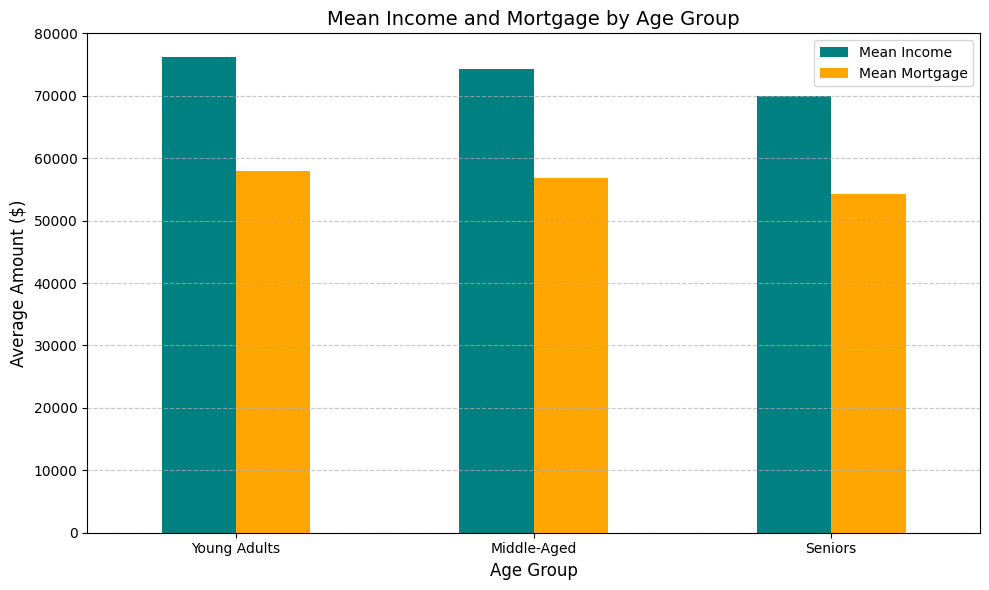

In [30]:
# Binning the 'Age' column into defined categories
bins = [20, 35, 55, 70]
labels = ['Young Adults', 'Middle-Aged', 'Seniors']
loans_df['AgeGroup'] = pd.cut(loans_df['Age'], bins=bins, labels=labels)

# Grouping by 'AgeGroup' and calculating the mean for Income and Mortgage
age_group_means = loans_df.groupby('AgeGroup', observed=True)[['Income', 'Mortgage']].mean()

# Plotting the mean values
ax = age_group_means.plot(kind='bar', figsize=(10, 6), color=['teal', 'orange'])

# Adding labels and title
plt.title('Mean Income and Mortgage by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Average Amount ($)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Mean Income', 'Mean Mortgage'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()


I will now proceed to the next subtask, which is to analyze and visualize the adoption rates for various banking services across the defined age groups using a grouped bar chart.



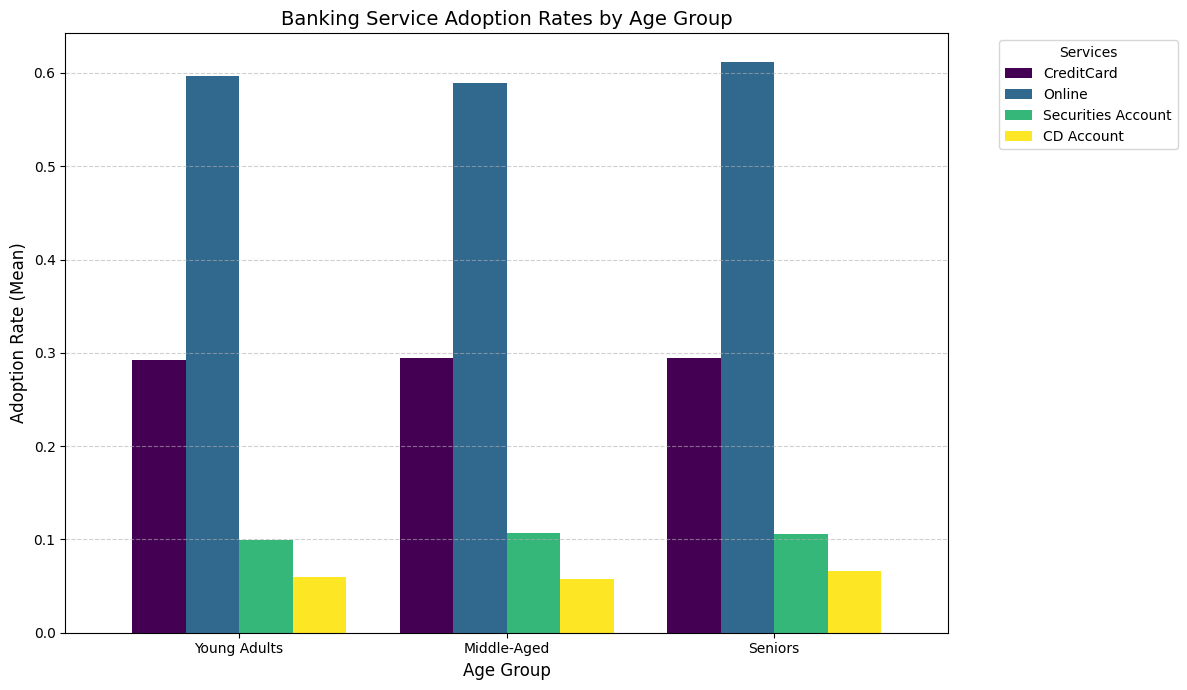

In [31]:
# Calculate adoption rates for services by AgeGroup
service_cols = ['CreditCard', 'Online', 'Securities Account', 'CD Account']
age_service_adoption = loans_df.groupby('AgeGroup', observed=True)[service_cols].mean()

# Plotting the service adoption rates by AgeGroup
ax = age_service_adoption.plot(kind='bar', figsize=(12, 7), width=0.8, colormap='viridis')

# Adding titles and labels
plt.title('Banking Service Adoption Rates by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Adoption Rate (Mean)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Services', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

### Summary of Age-Level Analysis Findings

* **Income Trends**: Young Adults (20-35) surprisingly exhibit the highest mean income in this dataset, followed by Middle-Aged customers, with Seniors having the lowest average income. This suggests the bank's younger clientele is highly professional or high-earning.
* **Mortgage Patterns**: Consistent with income levels, the average mortgage amount is highest among Young Adults and decreases slightly with age, indicating that younger customers in this dataset may be taking on more significant property investments.
* **Digital Engagement**: Online banking adoption is robust across all age groups, peaking slightly among Seniors (over 61%), which highlights the importance of digital platforms even for older demographics.
* **Investment Services**: Adoption of Securities Accounts and CD Accounts remains relatively stable across age groups, though Seniors show the highest rate of CD Account adoption (approximately 6.6%), aligning with a traditional shift toward lower-risk savings products in later life stages.
* **Credit Card Usage**: Credit card adoption rates are remarkably consistent across all three age categories, staying near 29%, showing that credit usage is a uniform behavior regardless of the customer's life stage.

## Final Executive Summary of Bank Customer Analysis

* **High-Value Segments**: Both Undergraduates (Level 1) and Young Adults (20-35) unexpectedly represent the highest-earning demographics, holding the highest mean incomes and mortgage balances in the dataset.
* **Digital Standard**: Online banking adoption is a universal standard across all segments, maintaining a robust usage rate of approximately 60% regardless of age or education level.
* **Family Life-Stages**: Family size peaks among Graduate-level customers (Education Level 2), whereas Young Adults and Undergraduates typically have smaller household units.
* **Savings Behavior**: While overall adoption of specialized products is low, Seniors (56+) show a distinct preference for CD Accounts, reflecting a traditional shift toward lower-risk savings in later life stages.
* **Credit Consistency**: Credit card utilization remains remarkably stable at approximately 29% across all demographic categories, indicating that basic credit usage is independent of age or academic attainment.